# Practical 5: Feature-Aware Matrix Factorization

In this practical, we extend our Matrix Factorization model to incorporate side information (genre features). 
This helps mitigate the "cold-start" problem for items with few or no ratings.

**Tasks:**
1. **Load Data & Features**: Load MovieLens data and extract user/item matrices and genre features.
2. **Feature Engineering**: Create a binary feature matrix from movie genres.
3. **Model Implementation**: Initialize and train the Feature-Aware ALS model.
4. **Hyperparameter Tuning**: Optimize \( K, \lambda, \tau, \lambda_{features} \).
5. **Cold Start Analysis**: Evaluate performance on items with few ratings.

In [18]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import optuna
from scipy import sparse

# Add project root to path
sys.path.append('..')

from src.data_loader import download_dataset, MovieLensDataset
from src.data_structures import RatingMatrix
from src.train_test_split import random_split
from src.features import load_genre_features
from src.als import MatrixFactorizationModel, FeatureAwareMatrixFactorizationModel

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Figure size 640x480 with 0 Axes>

## 1. Data Loading and Feature Extraction

In [19]:
# Load small dataset for development, verify logic
# DATASET_NAME = 'ml-latest-small'
DATASET_NAME = 'ml-32m' # Uncomment for full scale

data_path = download_dataset(DATASET_NAME, data_dir="../data")
dataset = MovieLensDataset(data_path)
print(dataset.summary())

Dataset already exists at ..\data\ml-32m
Loading ratings from ..\data\ml-32m\ratings.csv...
Loaded 32,000,204 ratings
MovieLens Dataset Summary
Users:          200,948
Items:           84,432
Ratings:     32,000,204
Sparsity:      99.8114%
Mean:             3.540



In [20]:
# Load Genre Features
feature_matrix, genre_names = load_genre_features(dataset)

print(f"\nFeature Matrix Shape: {feature_matrix.shape}")
print(f"Genres: {genre_names}")

Building genre feature matrix...
Loading movies from ..\data\ml-32m\movies.csv...
Loaded 87,585 movies
Found 19 unique genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Feature matrix statistics:
  Shape: (84432, 19)
  Stored elements: 142730
  Sparsity: 91.10%

Feature Matrix Shape: (84432, 19)
Genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


## 2. Train/Test Split

In [21]:
user_idx, item_idx, ratings = dataset.get_arrays()

train_data, test_data = random_split(
    user_idx, item_idx, ratings, test_ratio=0.2, seed=42
)

print(f"Train ratings: {len(train_data[2]):,}")
print(f"Test ratings:  {len(test_data[2]):,}")

# Build Train Matrix
train_matrix = RatingMatrix(
    train_data[0], train_data[1], train_data[2],
    n_users=dataset.n_users, n_items=dataset.n_items
)

Train ratings: 25,600,163
Test ratings:  6,400,041


## 3. Training Baseline Model

We first train a standard MF model as a baseline.

In [22]:
# Train Baseline Model (No Features)
print("Training Baseline MF Model...")
baseline_model = MatrixFactorizationModel(
    K=20, 
    lambda_=0.1, 
    tau=0.1, 
    n_iters=15,
    verbose=True
)
baseline_model.fit(train_matrix, test_data=test_data)
print(f"Baseline Test RMSE: {baseline_model.test_rmse_history[-1]:.4f}")

# Save baseline model
baseline_model.save('../models/feature_aware_baseline.npz')

Training Baseline MF Model...
Iter 1: Loss=829646.41, Train RMSE=0.7882, Test RMSE=0.9134 (31.15s)
Iter 2: Loss=704581.75, Train RMSE=0.7217, Test RMSE=0.8632 (7.23s)
Iter 3: Loss=641618.76, Train RMSE=0.6873, Test RMSE=0.8327 (8.71s)
Iter 4: Loss=612017.72, Train RMSE=0.6710, Test RMSE=0.8189 (8.24s)
Iter 5: Loss=595308.35, Train RMSE=0.6620, Test RMSE=0.8116 (8.19s)
Iter 6: Loss=584530.58, Train RMSE=0.6563, Test RMSE=0.8074 (8.20s)
Iter 7: Loss=577015.48, Train RMSE=0.6525, Test RMSE=0.8048 (7.37s)
Iter 8: Loss=571485.77, Train RMSE=0.6497, Test RMSE=0.8032 (9.23s)
Iter 9: Loss=567254.43, Train RMSE=0.6477, Test RMSE=0.8021 (8.55s)
Iter 10: Loss=563918.39, Train RMSE=0.6461, Test RMSE=0.8015 (7.53s)
Iter 11: Loss=561227.84, Train RMSE=0.6449, Test RMSE=0.8012 (9.05s)
Iter 12: Loss=559016.31, Train RMSE=0.6439, Test RMSE=0.8010 (8.34s)
Iter 13: Loss=557166.34, Train RMSE=0.6430, Test RMSE=0.8010 (7.50s)
Iter 14: Loss=555604.98, Train RMSE=0.6424, Test RMSE=0.8011 (8.85s)
Iter 15: Los

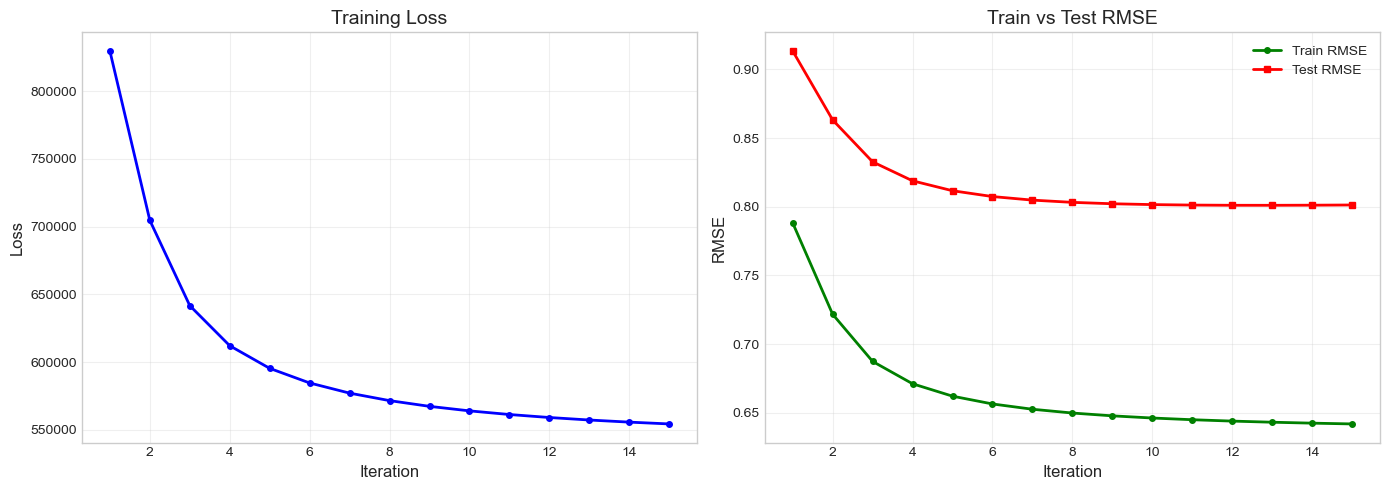

Final Train RMSE: 0.6418
Final Test RMSE:  0.8013


In [23]:
# Plot training metrics for baseline_model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
if hasattr(baseline_model, 'loss_history') and baseline_model.loss_history:
    iterations = range(1, len(baseline_model.loss_history) + 1)
    axes[0].plot(iterations, baseline_model.loss_history, 'b-o', linewidth=2, markersize=4)
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss', fontsize=14)
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'Loss history not available', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Training Loss', fontsize=14)

# RMSE plot
iterations = range(1, len(baseline_model.train_rmse_history) + 1)
axes[1].plot(iterations, baseline_model.train_rmse_history, 'g-o', linewidth=2, markersize=4, label='Train RMSE')
axes[1].plot(iterations, baseline_model.test_rmse_history, 'r-s', linewidth=2, markersize=4, label='Test RMSE')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Train vs Test RMSE', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/practical_5_baseline_model_training.pdf', format='pdf', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Train RMSE: {baseline_model.train_rmse_history[-1]:.4f}")
print(f"Final Test RMSE:  {baseline_model.test_rmse_history[-1]:.4f}")


## 4. Hyperparameter Tuning with Optuna

We use Optuna to find the optimal hyperparameters.
We tune:
- $K$ (Latent Dimension)
- $\lambda$ (Data Regularization)
- $\gamma$ (Bias Regularization)
- $\tau$ (Factor Regularization)

In [24]:
def objective(trial):
    # Sample hyperparameters as requested
    params = {
        'K': trial.suggest_categorical('K', [20]),
        'lambda_': trial.suggest_float('lambda_', 0.001, 0.01, log=True),
        'gamma': trial.suggest_float('gamma', 0.005, 0.05, log=True),
        'tau': trial.suggest_float('tau', 0.05, 0.2, log=True)
    }
    
    # Train model (fewer iterations for speed during search)
    # We fix lambda_features since it's not in the search space provided
    model = FeatureAwareMatrixFactorizationModel(
        **params,
        lambda_features=5.0, # Fixed value to ensure features are used
        n_iters=10,
        verbose=True
    )
    
    model.fit(train_matrix, feature_matrix=feature_matrix, test_data=test_data)
    
    return model.test_rmse_history[-1]

# Create study
study = optuna.create_study(direction='minimize')
print("Starting Optuna Optimization ...")
study.optimize(objective, n_trials=30)

print("\nBest parameters:", study.best_params)
print("Best RMSE:", study.best_value)

[I 2026-01-10 09:26:44,752] A new study created in memory with name: no-name-91b68b94-8b93-41fd-bdbe-bf41dbfb3a10


Starting Optuna Optimization ...
Iter 1: Loss=56555.84, Train RMSE=0.8506, Test RMSE=0.8686 (17.02s)
Iter 2: Loss=51959.60, Train RMSE=0.7983, Test RMSE=0.8275 (7.75s)
Iter 3: Loss=50327.45, Train RMSE=0.7697, Test RMSE=0.8063 (8.36s)
Iter 4: Loss=49826.68, Train RMSE=0.7599, Test RMSE=0.7988 (8.46s)
Iter 5: Loss=49579.51, Train RMSE=0.7554, Test RMSE=0.7952 (8.58s)
Iter 6: Loss=49417.10, Train RMSE=0.7528, Test RMSE=0.7931 (6.92s)
Iter 7: Loss=49292.93, Train RMSE=0.7511, Test RMSE=0.7917 (8.69s)
Iter 8: Loss=49190.52, Train RMSE=0.7500, Test RMSE=0.7908 (9.20s)
Iter 9: Loss=49101.62, Train RMSE=0.7490, Test RMSE=0.7901 (7.23s)


[I 2026-01-10 09:28:15,172] Trial 0 finished with value: 0.7895407676696777 and parameters: {'K': 20, 'lambda_': 0.005940877256420655, 'gamma': 0.009938553051011836, 'tau': 0.06552460935905902}. Best is trial 0 with value: 0.7895407676696777.


Iter 10: Loss=49022.77, Train RMSE=0.7483, Test RMSE=0.7895 (8.03s)
Iter 1: Loss=12445.37, Train RMSE=0.8655, Test RMSE=0.8706 (6.68s)
Iter 2: Loss=12108.36, Train RMSE=0.8564, Test RMSE=0.8615 (7.87s)
Iter 3: Loss=12093.37, Train RMSE=0.8559, Test RMSE=0.8610 (7.79s)
Iter 4: Loss=12088.76, Train RMSE=0.8558, Test RMSE=0.8609 (6.29s)
Iter 5: Loss=12086.01, Train RMSE=0.8557, Test RMSE=0.8609 (7.80s)
Iter 6: Loss=12084.28, Train RMSE=0.8557, Test RMSE=0.8608 (7.51s)
Iter 7: Loss=12083.17, Train RMSE=0.8556, Test RMSE=0.8608 (6.61s)
Iter 8: Loss=12082.47, Train RMSE=0.8556, Test RMSE=0.8607 (7.26s)
Iter 9: Loss=12082.02, Train RMSE=0.8556, Test RMSE=0.8607 (6.67s)


[I 2026-01-10 09:29:26,515] Trial 1 finished with value: 0.8607076406478882 and parameters: {'K': 20, 'lambda_': 0.0012408692095213188, 'gamma': 0.046198569687075156, 'tau': 0.11257154019831289}. Best is trial 0 with value: 0.7895407676696777.


...

Iter 10: Loss=71302.54, Train RMSE=0.7472, Test RMSE=0.7885 (7.64s)
Iter 1: Loss=33260.71, Train RMSE=0.8602, Test RMSE=0.8682 (7.29s)
Iter 2: Loss=32072.44, Train RMSE=0.8458, Test RMSE=0.8538 (8.13s)
Iter 3: Loss=31695.71, Train RMSE=0.8329, Test RMSE=0.8430 (7.37s)
Iter 4: Loss=31487.22, Train RMSE=0.8229, Test RMSE=0.8349 (6.57s)
Iter 5: Loss=31390.14, Train RMSE=0.8178, Test RMSE=0.8308 (6.63s)
Iter 6: Loss=31333.12, Train RMSE=0.8153, Test RMSE=0.8288 (6.91s)
Iter 7: Loss=31289.70, Train RMSE=0.8137, Test RMSE=0.8276 (6.99s)
Iter 8: Loss=31252.28, Train RMSE=0.8126, Test RMSE=0.8268 (7.73s)
Iter 9: Loss=31218.87, Train RMSE=0.8117, Test RMSE=0.8261 (7.07s)


[I 2026-01-10 10:00:25,835] Trial 28 finished with value: 0.8255695104598999 and parameters: {'K': 20, 'lambda_': 0.0033931724766490395, 'gamma': 0.04809742797573976, 'tau': 0.09131482712961948}. Best is trial 14 with value: 0.7806927561759949.


Iter 10: Loss=31188.53, Train RMSE=0.8109, Test RMSE=0.8256 (6.83s)
Iter 1: Loss=53923.94, Train RMSE=0.8501, Test RMSE=0.8687 (6.95s)
Iter 2: Loss=49502.61, Train RMSE=0.7975, Test RMSE=0.8272 (7.51s)
Iter 3: Loss=47944.28, Train RMSE=0.7690, Test RMSE=0.8061 (7.56s)
Iter 4: Loss=47464.02, Train RMSE=0.7593, Test RMSE=0.7985 (6.92s)
Iter 5: Loss=47226.07, Train RMSE=0.7548, Test RMSE=0.7949 (6.30s)
Iter 6: Loss=47069.47, Train RMSE=0.7522, Test RMSE=0.7928 (6.14s)
Iter 7: Loss=46949.59, Train RMSE=0.7505, Test RMSE=0.7915 (6.29s)
Iter 8: Loss=46850.32, Train RMSE=0.7494, Test RMSE=0.7905 (6.56s)
Iter 9: Loss=46764.18, Train RMSE=0.7484, Test RMSE=0.7898 (6.77s)


[I 2026-01-10 10:01:33,756] Trial 29 finished with value: 0.789251983165741 and parameters: {'K': 20, 'lambda_': 0.005666082625057777, 'gamma': 0.009265432014338243, 'tau': 0.05863637672695905}. Best is trial 14 with value: 0.7806927561759949.


Iter 10: Loss=46687.52, Train RMSE=0.7477, Test RMSE=0.7893 (6.80s)

Best parameters: {'K': 20, 'lambda_': 0.009788851352111277, 'gamma': 0.024422921095404705, 'tau': 0.09057852893136299}
Best RMSE: 0.7806927561759949


### HPO Visualizations

In [25]:
from optuna.visualization import plot_optimization_history, plot_slice, plot_param_importances

# Provide visualizations
# Note: These are interactive plotly figures. In some environments they might need adjustments.
try:
    fig1 = plot_optimization_history(study)
    fig1.show()
    
    fig2 = plot_slice(study)
    fig2.show()
    
    fig3 = plot_param_importances(study)
    fig3.show()

    # Save Hyperparameter Importance Plot
    try:
        # Requires kaleido or orca
        fig3.write_image("../figures/practical_5_hyperparameter_importance.pdf")
        print("Saved hyperparameter importance plots to SVG")
    except Exception as e:
        print(f"Could not save plotly figure to SVG (missing dependencies?): {e}")

except Exception as e:
    print(f"Could not plot visualizations: {e}")

Could not save plotly figure to SVG (missing dependencies?): 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



## 5. Training Feature-Aware ALS (Best Params)

In [26]:
# Train Feature-Aware Model with Best Params
best_params = study.best_params
print("\nTraining Feature-Aware MF Model with Best Params...")

# We must ensure lambda_features is passed if it wasn't tuned, or handled by **best_params if it was.
# Since we removed it from tuning, we set it explicitly or rely on best_params not having it.
feature_model = FeatureAwareMatrixFactorizationModel(
    **best_params,
    lambda_features=5.0, # Keep consistent with search
    n_iters=30,
    verbose=True
)
feature_model.fit(train_matrix, feature_matrix=feature_matrix, test_data=test_data)
print(f"Feature-Aware Test RMSE: {feature_model.test_rmse_history[-1]:.4f}")

# Save final feature-aware model
feature_model.save('../models/feature_aware_final.npz')
print('Final feature-aware model saved to ../models/feature_aware_final.npz')


Training Feature-Aware MF Model with Best Params...
Iter 1: Loss=92532.68, Train RMSE=0.8437, Test RMSE=0.8685 (7.70s)
Iter 2: Loss=83038.63, Train RMSE=0.7776, Test RMSE=0.8213 (8.38s)
Iter 3: Loss=79979.27, Train RMSE=0.7500, Test RMSE=0.7995 (7.51s)
Iter 4: Loss=78955.72, Train RMSE=0.7404, Test RMSE=0.7912 (7.04s)
Iter 5: Loss=78435.02, Train RMSE=0.7357, Test RMSE=0.7870 (6.90s)
Iter 6: Loss=78105.38, Train RMSE=0.7330, Test RMSE=0.7846 (7.10s)
Iter 7: Loss=77866.84, Train RMSE=0.7312, Test RMSE=0.7831 (6.98s)
Iter 8: Loss=77679.83, Train RMSE=0.7300, Test RMSE=0.7821 (7.06s)
Iter 9: Loss=77524.98, Train RMSE=0.7290, Test RMSE=0.7813 (7.10s)
Iter 10: Loss=77392.56, Train RMSE=0.7283, Test RMSE=0.7807 (6.96s)
Iter 11: Loss=77277.03, Train RMSE=0.7276, Test RMSE=0.7802 (7.20s)
Iter 12: Loss=77175.07, Train RMSE=0.7271, Test RMSE=0.7798 (6.84s)
Iter 13: Loss=77083.82, Train RMSE=0.7266, Test RMSE=0.7795 (7.52s)
Iter 14: Loss=77002.34, Train RMSE=0.7262, Test RMSE=0.7792 (6.91s)
Iter

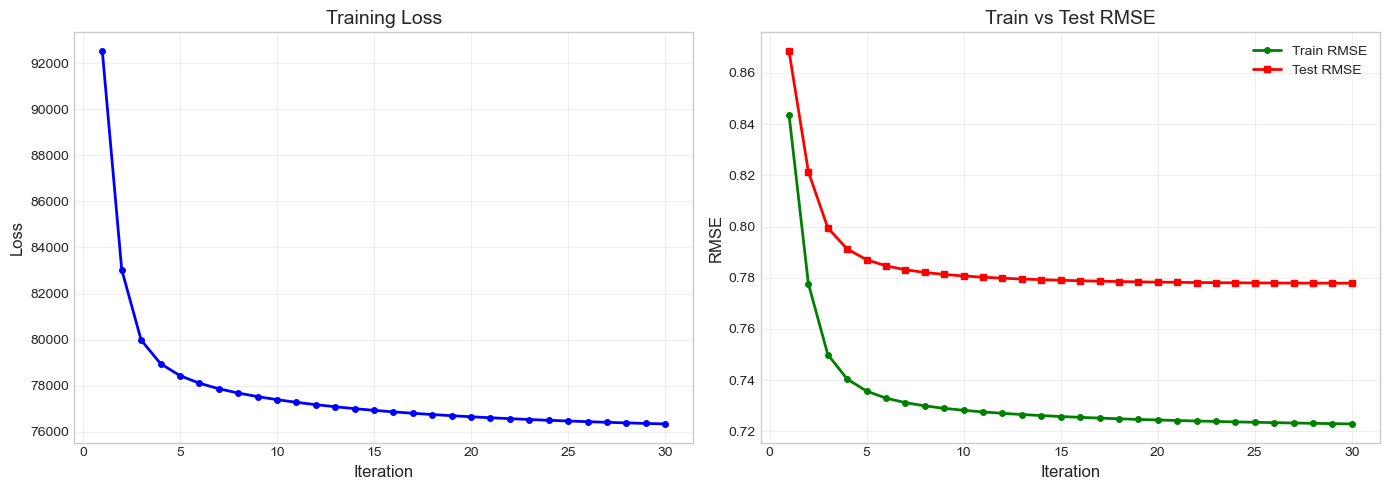

Final Train RMSE: 0.7229
Final Test RMSE:  0.7779


In [27]:
# Plot training metrics for feature_model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
if hasattr(feature_model, 'loss_history') and feature_model.loss_history:
    iterations = range(1, len(feature_model.loss_history) + 1)
    axes[0].plot(iterations, feature_model.loss_history, 'b-o', linewidth=2, markersize=4)
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss', fontsize=14)
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'Loss history not available', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Training Loss', fontsize=14)

# RMSE plot
iterations = range(1, len(feature_model.train_rmse_history) + 1)
axes[1].plot(iterations, feature_model.train_rmse_history, 'g-o', linewidth=2, markersize=4, label='Train RMSE')
axes[1].plot(iterations, feature_model.test_rmse_history, 'r-s', linewidth=2, markersize=4, label='Test RMSE')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Train vs Test RMSE', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/practical_5_feature_model_training.pdf', format='pdf', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Train RMSE: {feature_model.train_rmse_history[-1]:.4f}")
print(f"Final Test RMSE:  {feature_model.test_rmse_history[-1]:.4f}")


## 6. Cold Start Analysis


In [28]:
def analyze_rmse_by_popularity(model, test_data, train_matrix, n_bins=5):
    test_users, test_items, test_ratings = test_data
    preds = model.predict(test_users, test_items)
    squared_errors = (test_ratings - preds) ** 2
    
    # Get item popularity from training data
    item_counts = train_matrix.get_item_counts()
    
    # Get counts for items in test set
    test_item_counts = item_counts[test_items]
    
    # Create bins
    # 0, 1-5, 6-20, 21-100, 100+
    bins = [0, 5, 20, 100, np.inf]
    labels = ['0-5', '6-20', '21-100', '100+']
    
    results = []
    for i in range(len(bins)-1):
        mask = (test_item_counts > bins[i]) & (test_item_counts <= bins[i+1])
        if np.sum(mask) > 0:
            rmse = np.sqrt(np.mean(squared_errors[mask]))
            count = np.sum(mask)
            results.append({'Bin': labels[i], 'RMSE': rmse, 'Count': count})
            
    return pd.DataFrame(results)

print("Baseline Cold Start Analysis:")
df_base = analyze_rmse_by_popularity(baseline_model, test_data, train_matrix)
print(df_base)

print("\nFeature-Aware Cold Start Analysis:")
df_feat = analyze_rmse_by_popularity(feature_model, test_data, train_matrix)
print(df_feat)

Baseline Cold Start Analysis:
      Bin      RMSE    Count
0     0-5  0.961798    22261
1    6-20  0.914289    40612
2  21-100  0.880470   110736
3    100+  0.798114  6221685

Feature-Aware Cold Start Analysis:
      Bin      RMSE    Count
0     0-5  0.924718    22261
1    6-20  0.875036    40612
2  21-100  0.848999   110736
3    100+  0.775055  6221685


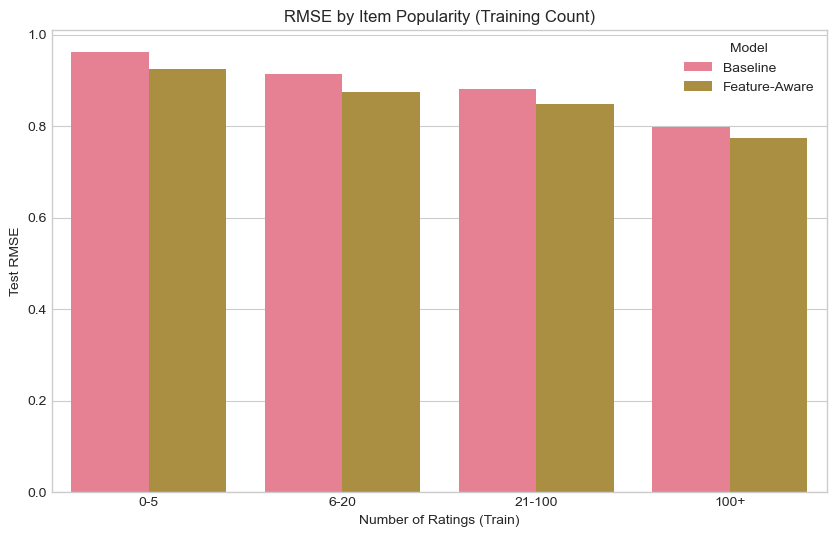

In [29]:
# Plot comparison
df_base['Model'] = 'Baseline'
df_feat['Model'] = 'Feature-Aware'
df_combined = pd.concat([df_base, df_feat])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_combined, x='Bin', y='RMSE', hue='Model')
plt.title('RMSE by Item Popularity (Training Count)')
plt.xlabel('Number of Ratings (Train)')
plt.ylabel('Test RMSE')
plt.savefig('../figures/practical_5_rmse_by_popularity.pdf', format='pdf')
plt.show()

## 7. Investigating Feature Embeddings

We can look at the learned feature embeddings ($W$) to see if they capture semantic meaning.

Feature Embeddings Shape: (19, 20)


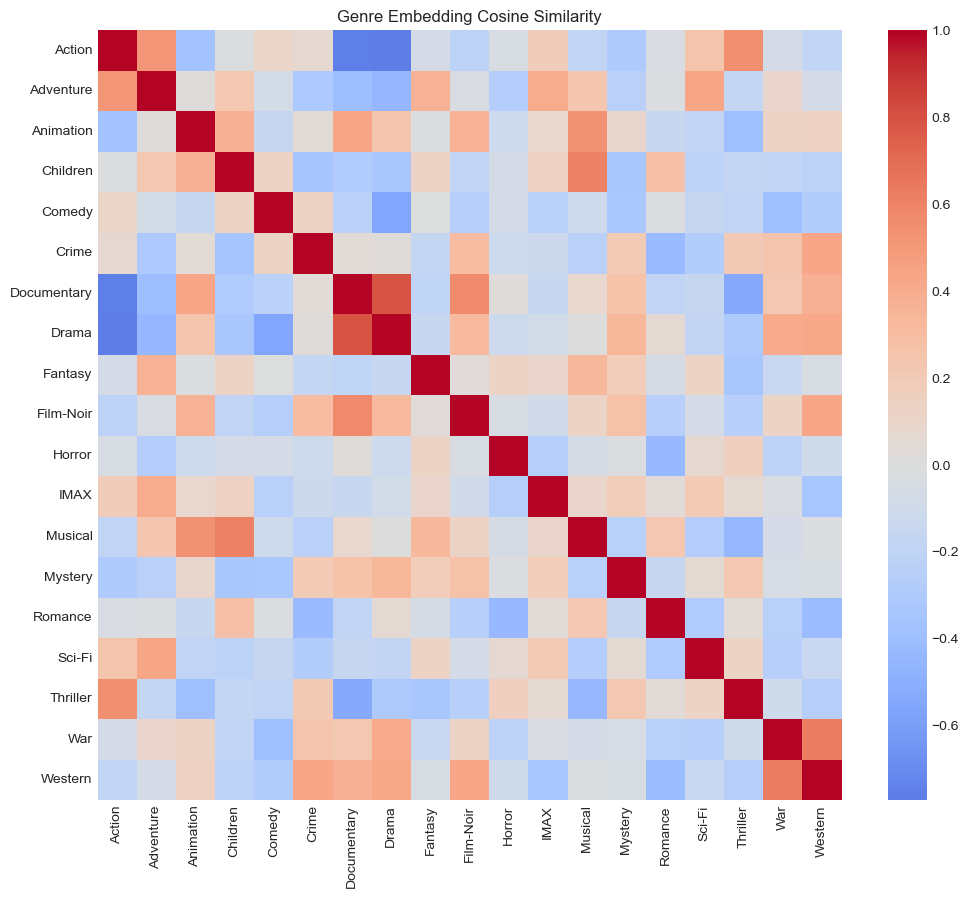

In [30]:
# Visualize Feature Similarities if possible, or just print dimensions
W = feature_model.feature_factors
print(f"Feature Embeddings Shape: {W.shape}")

# Compute similarity between genres
# Normalize rows
norms = np.linalg.norm(W, axis=1, keepdims=True)
W_norm = W / (norms + 1e-9)
sim_matrix = W_norm @ W_norm.T

plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, xticklabels=genre_names, yticklabels=genre_names, cmap='coolwarm', center=0)
plt.title('Genre Embedding Cosine Similarity')
plt.savefig('../figures/practical_5_feature_embedding_similarity.pdf', format='pdf')
plt.show()